# Preprocesamiento y análisis del dataset Couinaud (U-Net 2D multiclase)

Este notebook documenta el flujo de **análisis y preprocesamiento** aplicado al dataset de Medical Segmentation Decathlon (task 8, hepatic vessels and tumor) y las anotaciones de Couinaud del paper “Automatic Couinaud Segmentation from CT Volumes on Liver Using GLC-UNet“ para entrenar una U-Net 2D multiclase (fondo + segmentos hepáticos).

## Objetivos
1. Explorar la estructura del dataset (imágenes y anotaciones).
2. Matchear imágenes con sus máscaras (por nombre base).
3. Revisar metadatos básicos (shape, spacing/affine).
4. Analizar intensidades (HU) y definir una **ventana** adecuada.
5. Aplicar: **ventaneo + normalización** y visualizar resultados.
6. Analizar distribución de **cantidad de slices** por paciente y exportar CSV.

In [1]:
# Imports básicos y definición de rutas

import os
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import csv
import numpy as np
from collections import Counter

# Ruta base del dataset Couinaud en tu servidor
BASE_DIR = "/users/lvelez/PI_Velez/data/Couinaud"

# Carpeta con las imágenes de entrenamiento (CTs)
IMAGES_TR_DIR = os.path.join(BASE_DIR, "imagesTr")

# Carpeta con las imágenes de entrenamiento (CTs)
IMAGES_TS_DIR = os.path.join(BASE_DIR, "imagesTs")

# Carpeta con las anotaciones Couinaud (máscaras)
COUINAUD_DIR = os.path.join(BASE_DIR, "couinaud_annotation")

## 1. Listar y revisar las imágenes de `imagesTr`

En esta celda:

- Listamos todos los archivos NIfTI de la carpeta `imagesTr`.
- Cargamos cada volumen para inspeccionar su `shape` y `dtype`.
- Guardamos esta información en una lista de diccionarios (`images_info`), que luego usaremos para matchear con las anotaciones de Couinaud.


In [2]:
image_files = [
    f for f in os.listdir(IMAGES_TR_DIR)
    if f.endswith(".nii") or f.endswith(".nii.gz")
]
image_files = sorted(image_files)

print(f"Encontré {len(image_files)} archivos en imagesTr\n")
for f in image_files[:5]:
    print(" -", f)

images_info = []

for fname in image_files:
    path = os.path.join(IMAGES_TR_DIR, fname)
    img_nii = nib.load(path)
    img_data = img_nii.get_fdata()

    images_info.append({
        "file": fname,
        "shape": img_data.shape,
        "dtype": img_data.dtype,
    })

Encontré 303 archivos en imagesTr

 - hepaticvessel_001.nii.gz
 - hepaticvessel_002.nii.gz
 - hepaticvessel_004.nii.gz
 - hepaticvessel_005.nii.gz
 - hepaticvessel_007.nii.gz


## 2. Listar y revisar las imágenes de `imagesTs`

In [3]:
# Listar y analizar las imágenes de imagesTs

image_ts_files = [
    f for f in os.listdir(IMAGES_TS_DIR)
    if f.endswith(".nii") or f.endswith(".nii.gz")
]
image_ts_files = sorted(image_ts_files)

print(f"Encontré {len(image_ts_files)} archivos en imagesTs\n")
for f in image_ts_files[:5]:
    print(" -", f)

images_ts_info = []

for fname in image_ts_files:
    path = os.path.join(IMAGES_TS_DIR, fname)
    img_nii = nib.load(path)
    img_data = img_nii.get_fdata()

    images_ts_info.append({
        "file": fname,
        "shape": img_data.shape,
        "dtype": img_data.dtype,
    })

print("\nPrimeros 5 resultados de imagesTs:")
for entry in images_ts_info[:5]:
    print(entry)

Encontré 71 archivos en imagesTs

 - hepaticvessel_003.nii.gz
 - hepaticvessel_009.nii.gz
 - hepaticvessel_012.nii.gz
 - hepaticvessel_014.nii.gz
 - hepaticvessel_015.nii.gz

Primeros 5 resultados de imagesTs:
{'file': 'hepaticvessel_003.nii.gz', 'shape': (512, 512, 39), 'dtype': dtype('float64')}
{'file': 'hepaticvessel_009.nii.gz', 'shape': (512, 512, 37), 'dtype': dtype('float64')}
{'file': 'hepaticvessel_012.nii.gz', 'shape': (512, 512, 49), 'dtype': dtype('float64')}
{'file': 'hepaticvessel_014.nii.gz', 'shape': (512, 512, 87), 'dtype': dtype('float64')}
{'file': 'hepaticvessel_015.nii.gz', 'shape': (512, 512, 43), 'dtype': dtype('float64')}


## 3. Listar y revisar las anotaciones de `couinaud_annotation`

En esta celda:

- Listamos todos los archivos de la carpeta `couinaud_annotation`.
- Cargamos las máscaras para ver su `shape` y `dtype`.
- Guardamos la información en `couinaud_info`.

Más adelante, vamos a usar el "nombre base" (sin extensión) de estos archivos para matchearlos con las imágenes de `imagesTr`.


In [4]:
couinaud_files = [
    f for f in os.listdir(COUINAUD_DIR)
    if f.endswith(".nii")  # en este dataset vienen como .nii
]
couinaud_files = sorted(couinaud_files)

print(f"Encontré {len(couinaud_files)} archivos en couinaud_annotation\n")
for f in couinaud_files[:5]:
    print(" -", f)

couinaud_info = []

for fname in couinaud_files:
    path = os.path.join(COUINAUD_DIR, fname)
    couinaud_nii = nib.load(path)
    couinaud_data = couinaud_nii.get_fdata()

    couinaud_info.append({
        "file": fname,
        "shape": couinaud_data.shape,
        "dtype": couinaud_data.dtype,
    })

Encontré 193 archivos en couinaud_annotation

 - hepaticvessel_001.nii
 - hepaticvessel_002.nii
 - hepaticvessel_003.nii
 - hepaticvessel_004.nii
 - hepaticvessel_005.nii


## Análisis de etiquetas (clases) en las máscaras de Couinaud

En esta celda:

- Extraemos las **etiquetas únicas** presentes en cada archivo de segmentación.
- Verificamos cuáles son las etiquetas globales del dataset (incluyendo fondo).
- Separamos explícitamente el **fondo (0)** de los **segmentos hepáticos**.
- Chequeamos si el dataset contiene **8 o 9 segmentos**, lo cual es relevante para:
  - definir el número de clases del modelo
  - **interpretar correctamente la segmentación del segmento IV (IVa / IVb)**

Este paso es clave para evitar errores silenciosos en el entrenamiento de la U-Net multiclase.

In [5]:
# Para guardar info de etiquetas por archivo
labels_per_file = []
all_labels = set()

for fname in couinaud_files:
    path = os.path.join(COUINAUD_DIR, fname)
    couinaud_nii = nib.load(path)
    couinaud_data = couinaud_nii.get_fdata()

    # Pasamos a int por las dudas (get_fdata suele dar float64)
    labels = np.unique(couinaud_data.astype(np.int16))
    
    labels_per_file.append({
        "file": fname,
        "labels": labels
    })
    
    all_labels.update(labels.tolist())

print("Etiquetas distintas globales (incluyendo fondo):", sorted(all_labels))

# Quitamos el fondo (asumiendo que el fondo es 0)
segment_labels = sorted([l for l in all_labels if l != 0])
print("Etiquetas de segmentos (sin fondo):", segment_labels)
print("Número de clases de segmentos (sin fondo):", len(segment_labels))

# Chequeo específico para el tema 8 vs 9 segmentos
if len(segment_labels) == 8:
    print("\n→ Hay 8 clases de segmentos (sin fondo).")
elif len(segment_labels) == 9:
    print("\n→ OJO: hay 9 clases de segmentos (sin fondo). Probable separación de 4a y 4b.")
else:
    print("\n→ Número inesperado de clases de segmentos:", len(segment_labels))

# Si querés ver un resumen de los primeros archivos:
print("\nPrimeros 10 archivos y sus etiquetas:")
for entry in labels_per_file[:10]:
    print(f"- {entry['file']}: {entry['labels']}")

Etiquetas distintas globales (incluyendo fondo): [0, 1, 2, 3, 4, 5, 6, 7, 8]
Etiquetas de segmentos (sin fondo): [1, 2, 3, 4, 5, 6, 7, 8]
Número de clases de segmentos (sin fondo): 8

→ Hay 8 clases de segmentos (sin fondo).

Primeros 10 archivos y sus etiquetas:
- hepaticvessel_001.nii: [0 1 2 3 4 5 6 7 8]
- hepaticvessel_002.nii: [0 1 2 3 4 5 6 7 8]
- hepaticvessel_003.nii: [0 1 2 3 4 5 6 7 8]
- hepaticvessel_004.nii: [0 1 2 3 4 5 6 7 8]
- hepaticvessel_005.nii: [0 1 3 4 7 8]
- hepaticvessel_009.nii: [0 1 2 3 4 5 6 7 8]
- hepaticvessel_010.nii: [0 1 2 3 4 5 6 7 8]
- hepaticvessel_011.nii: [0 1 2 3 4 5 6 7 8]
- hepaticvessel_013.nii: [0 1 2 3 4 5 6 7 8]
- hepaticvessel_015.nii: [0 1 2 3 4 5 6 7 8]


## 4. Matchear imágenes y anotaciones por nombre base para imagesTr y tambien imagesTs

Los archivos de `imagesTr` y de `couinaud_annotation` se pueden relacionar por su nombre base (por ejemplo, `hepaticvessel_001`).

En esta celda:

- Definimos una función `base_name()` que elimina la extensión.
- Construimos dos diccionarios:
  - `images_by_base`: nombre base → info de la imagen CT.
  - `couinaud_by_base`: nombre base → info de la máscara Couinaud.
- Recorremos los nombres base que están en **ambos** diccionarios y creamos una lista `matched_tr` solo con:
  - las imágenes de `imagesTr` que tienen una máscara en `couinaud_annotation`,
  - y cuyos `shape` coinciden (para asegurarnos que están alineadas).

Hacemos lo mismo con imagesTs en matched_ts.

In [6]:
import shutil

# Carpetas de salida dentro del mismo BASE_DIR
COUINAUD_TR_DIR = os.path.join(BASE_DIR, "CouinaudTr")
COUINAUD_TS_DIR = os.path.join(BASE_DIR, "CouinaudTs")

os.makedirs(COUINAUD_TR_DIR, exist_ok=True)
os.makedirs(COUINAUD_TS_DIR, exist_ok=True)

def base_name(fname: str) -> str:
    """
    Devuelve el nombre base sin extensión .nii o .nii.gz.
    Ejemplo:
      'hepaticvessel_001.nii.gz' -> 'hepaticvessel_001'
      'hepaticvessel_001.nii'    -> 'hepaticvessel_001'
    """
    if fname.endswith(".nii.gz"):
        return fname[:-7]
    elif fname.endswith(".nii"):
        return fname[:-4]
    else:
        return os.path.splitext(fname)[0]


# 1) Construir diccionarios base_name -> info
images_tr_by_base = {}
for info in images_info:        # viene de tu celda de imagesTr
    b = base_name(info["file"])
    images_tr_by_base[b] = info

images_ts_by_base = {}
for info in images_ts_info:     # viene de tu celda de imagesTs
    b = base_name(info["file"])
    images_ts_by_base[b] = info

couinaud_by_base = {}
for info in couinaud_info:      # viene de tu celda de couinaud_annotation
    b = base_name(info["file"])
    couinaud_by_base[b] = info

# 2) Matchear por nombre base y shape
matched_tr = []  # (base, img_file, mask_file)
matched_ts = []

for b, cinfo in couinaud_by_base.items():
    # Match con imagesTr
    if b in images_tr_by_base:
        iinfo = images_tr_by_base[b]
        if iinfo["shape"] == cinfo["shape"]:
            matched_tr.append((b, iinfo["file"], cinfo["file"]))

    # Match con imagesTs
    if b in images_ts_by_base:
        iinfo = images_ts_by_base[b]
        if iinfo["shape"] == cinfo["shape"]:
            matched_ts.append((b, iinfo["file"], cinfo["file"]))

print(f"Casos matcheados Train (imagesTr + Couinaud): {len(matched_tr)}")
print(f"Casos matcheados Test  (imagesTs + Couinaud): {len(matched_ts)}\n")

print("Ejemplos Train:")
for b, img_f, mask_f in matched_tr[:5]:
    print(f"  base={b} | img={img_f} | mask={mask_f}")

print("\nEjemplos Test:")
for b, img_f, mask_f in matched_ts[:5]:
    print(f"  base={b} | img={img_f} | mask={mask_f}")


# 3) Copiar archivos a CouinaudTr y CouinaudTs
def copiar_parejas(matched_list, images_dir, out_dir):
    for b, img_f, mask_f in matched_list:
        src_img  = os.path.join(images_dir, img_f)
        src_mask = os.path.join(COUINAUD_DIR, mask_f)

        dst_img  = os.path.join(out_dir, img_f)
        dst_mask = os.path.join(out_dir, mask_f)

        shutil.copy2(src_img,  dst_img)
        shutil.copy2(src_mask, dst_mask)

    print(f"\nCopiados {len(matched_list)} CT + {len(matched_list)} máscaras a {out_dir}")

copiar_parejas(matched_tr, IMAGES_TR_DIR, COUINAUD_TR_DIR)
copiar_parejas(matched_ts, IMAGES_TS_DIR, COUINAUD_TS_DIR)

Casos matcheados Train (imagesTr + Couinaud): 161
Casos matcheados Test  (imagesTs + Couinaud): 32

Ejemplos Train:
  base=hepaticvessel_001 | img=hepaticvessel_001.nii.gz | mask=hepaticvessel_001.nii
  base=hepaticvessel_002 | img=hepaticvessel_002.nii.gz | mask=hepaticvessel_002.nii
  base=hepaticvessel_004 | img=hepaticvessel_004.nii.gz | mask=hepaticvessel_004.nii
  base=hepaticvessel_005 | img=hepaticvessel_005.nii.gz | mask=hepaticvessel_005.nii
  base=hepaticvessel_010 | img=hepaticvessel_010.nii.gz | mask=hepaticvessel_010.nii

Ejemplos Test:
  base=hepaticvessel_003 | img=hepaticvessel_003.nii.gz | mask=hepaticvessel_003.nii
  base=hepaticvessel_009 | img=hepaticvessel_009.nii.gz | mask=hepaticvessel_009.nii
  base=hepaticvessel_015 | img=hepaticvessel_015.nii.gz | mask=hepaticvessel_015.nii
  base=hepaticvessel_017 | img=hepaticvessel_017.nii.gz | mask=hepaticvessel_017.nii
  base=hepaticvessel_021 | img=hepaticvessel_021.nii.gz | mask=hepaticvessel_021.nii

Copiados 161 CT +

## 5. Inspección de metadatos y espaciado espacial (`imagesTr`) 

En esta sección se analizan los **metadatos NIfTI** de las imágenes de `imagesTr` para:

- inspeccionar la matriz **affine** y el **header** de un volumen de ejemplo,
- extraer el tamaño del voxel en cada eje (`pixdim`),
- y analizar el **espaciado entre cortes (eje Z)** y la cantidad de slices por paciente.

Esta información resulta clave para entender la resolución espacial del dataset y
tomar decisiones informadas durante el preprocesamiento, como el **ventaneo** y el manejo de slices.


In [7]:
import os
import nibabel as nib

# Usamos el primer archivo de imagesTr
first_fname = image_files[1]
first_path = os.path.join(IMAGES_TR_DIR, first_fname)

print("Primer NIfTI en imagesTr:")
print("  Nombre:", first_fname)
print("  Ruta  :", first_path)
print()

# Cargamos el NIfTI
img_nii = nib.load(first_path)

# --- Affine ---
print("=== Affine ===")
print(img_nii.affine)
print()

# --- Header completo ---
hdr = img_nii.header
print("=== Header completo (nibabel) ===")
print(hdr)
print()

Primer NIfTI en imagesTr:
  Nombre: hepaticvessel_002.nii.gz
  Ruta  : /users/lvelez/PI_Velez/data/Couinaud/imagesTr/hepaticvessel_002.nii.gz

=== Affine ===
[[   0.95117199    0.            0.         -486.04888916]
 [   0.            0.95117199    0.         -486.04888916]
 [   0.            0.            3.75          0.        ]
 [   0.            0.            0.            1.        ]]

=== Header completo (nibabel) ===
<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : np.bytes_(b'')
db_name         : np.bytes_(b'')
extents         : 0
session_error   : 0
regular         : np.bytes_(b'r')
dim_info        : 0
dim             : [  3 512 512  66   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : float32
bitpix          : 32
slice_start     : 0
pixdim          : [1.       0.951172 0.951172 3.75     0.       0.       0.       0.      ]
vox_offset      : 0.0
scl_slope

In [8]:
# Archivo CSV de salida (en la carpeta del notebook)
csv_path = "imagesTr_pixdim_info.csv"

rows = []

for fname in image_files:  # image_files ya lo tenés definido
    path = os.path.join(IMAGES_TR_DIR, fname)
    img_nii = nib.load(path)
    hdr = img_nii.header

    # dim: [ndim, Nx, Ny, Nz, ...]
    dim = hdr.get("dim", None)
    if dim is not None:
        num_slices = int(dim[3])  # Nz
    else:
        data = img_nii.get_fdata()
        num_slices = data.shape[2] if data.ndim >= 3 else 1

    pixdim = hdr.get("pixdim", None)
    if pixdim is not None:
        # NIfTI: pixdim[1], pixdim[2], pixdim[3]
        voxel_x = float(pixdim[1])
        voxel_y = float(pixdim[2])
        voxel_z = float(pixdim[3])
    else:
        voxel_x = voxel_y = voxel_z = np.nan

    rows.append([fname, num_slices, voxel_x, voxel_y, voxel_z])

# Guardar CSV
with open(csv_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["file", "num_slices", "pixdim_x_mm", "pixdim_y_mm", "pixdim_z_mm"])
    writer.writerows(rows)

print(f"Información guardada en: {csv_path}\n")

# Explicación de pixdim
print("Interpretación de pixdim en NIfTI:")
print("  pixdim[0] → no se usa")
print("  pixdim[1] → tamaño del voxel en X (mm)")
print("  pixdim[2] → tamaño del voxel en Y (mm)")
print("  pixdim[3] → tamaño del voxel en Z (mm) (espaciado entre cortes / slice thickness)")

# Resumen rápido de valores únicos de pixdim (X,Y,Z)
unique_spacings = sorted({(r[2], r[3], r[4]) for r in rows})
print("\nEspaciados (X,Y,Z) únicos encontrados en imagesTr:")
for sx, sy, sz in unique_spacings:
    print(f"  ({sx:.6f}, {sy:.6f}, {sz:.6f})")

# 👉 Conteo de pacientes por valor de pixdim_z
pixdim_z_vals = [r[4] for r in rows if not np.isnan(r[4])]
counter_z = Counter(pixdim_z_vals)

print("\nPacientes por valor de pixdim_z (mm):")
for z_val, count in sorted(counter_z.items()):
    print(f"  {z_val:.6f} mm : {count} pacientes")

Información guardada en: imagesTr_pixdim_info.csv

Interpretación de pixdim en NIfTI:
  pixdim[0] → no se usa
  pixdim[1] → tamaño del voxel en X (mm)
  pixdim[2] → tamaño del voxel en Y (mm)
  pixdim[3] → tamaño del voxel en Z (mm) (espaciado entre cortes / slice thickness)

Espaciados (X,Y,Z) únicos encontrados en imagesTr:
  (0.568359, 0.568359, 2.500000)
  (0.585938, 0.585938, 5.000000)
  (0.609375, 0.609375, 5.000000)
  (0.609375, 0.609375, 7.500000)
  (0.611328, 0.611328, 5.000000)
  (0.623047, 0.623047, 1.500000)
  (0.625000, 0.625000, 5.000000)
  (0.626953, 0.626953, 2.500000)
  (0.632812, 0.632812, 5.000000)
  (0.638672, 0.638672, 5.000000)
  (0.640625, 0.640625, 5.000000)
  (0.642578, 0.642578, 5.000000)
  (0.644531, 0.644531, 1.500000)
  (0.644531, 0.644531, 5.000000)
  (0.650391, 0.650391, 1.500000)
  (0.664062, 0.664062, 5.000000)
  (0.664062, 0.664062, 7.000000)
  (0.664062, 0.664062, 7.500000)
  (0.673828, 0.673828, 2.500000)
  (0.673828, 0.673828, 5.000000)
  (0.673828,

## 6. Analizar las intensidades de un volumen de CT y posible paso a valores de Hounsfield

Antes de definir una ventana fija de Hounsfield para el hígado, es útil explorar las intensidades reales que trae el volumen tal como está guardado en el archivo NIfTI.

En esta sección:

- Seleccionamos una imagen de `imagesTr` (por defecto, el primer archivo de la carpeta).
- Cargamos el volumen y calculamos:
  - valor mínimo y máximo de intensidades
  - la media y la desviación estándar
- Graficamos un histograma de las intensidades tal como vienen en el NIfTI.
- Intentamos realizar un “paso” a valores de Hounsfield usando los campos `scl_slope` y `scl_inter` del header, si estuvieran definidos:
  - Si `scl_slope` y `scl_inter` son valores finitos, aplicamos:  
    \\(\text{HU} = \text{voxel} \times \text{slope} + \text{intercept}\\)  
    y graficamos un segundo histograma en HU.
  - Si esos campos no están bien definidos (por ejemplo, `NaN`), mostramos un mensaje indicando que no es posible recuperar HU a partir de ese NIfTI y solo usamos las intensidades tal como vienen.

Esta exploración nos ayuda a decidir luego qué ventana de intensidades tiene sentido usar para resaltar el hígado y tejidos blandos.

Analizando intensidades del archivo:
  Nombre: hepaticvessel_005.nii.gz
  Ruta  : /users/lvelez/PI_Velez/data/Couinaud/imagesTr/hepaticvessel_005.nii.gz

Estadísticas de intensidades (tal como vienen en el NIfTI):
  min         : -1024.00
  max         : 1240.00
  media       : -704.32
  desvío std  : 444.51

Información de reescalado (header NIfTI):
  scl_slope   : nan
  scl_inter   : nan

 No se pudo hacer conversión a HU.
   scl_slope o scl_inter no son valores finitos.
   Se vuelve a mostrar el histograma con las intensidades originales.


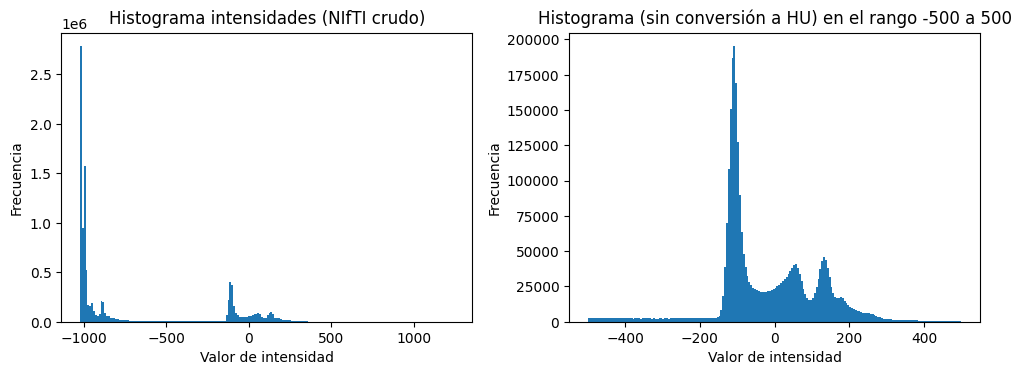

In [9]:
# ---------------------------------------------------------
# Analizar intensidades de un archivo NIfTI de imagesTr
# ---------------------------------------------------------

# Usamos el primer archivo listado en imagesTr (podés cambiar el índice)
first_fname = image_files[3]
first_path = os.path.join(IMAGES_TR_DIR, first_fname)

print("Analizando intensidades del archivo:")
print("  Nombre:", first_fname)
print("  Ruta  :", first_path)
print()

# Cargar NIfTI
img_nii = nib.load(first_path)
data = img_nii.get_fdata(dtype=np.float32)

# Estadísticas básicas de intensidades
vmin = float(data.min())
vmax = float(data.max())
mean = float(data.mean())
std  = float(data.std())

print("Estadísticas de intensidades (tal como vienen en el NIfTI):")
print(f"  min         : {vmin:.2f}")
print(f"  max         : {vmax:.2f}")
print(f"  media       : {mean:.2f}")
print(f"  desvío std  : {std:.2f}")
print()

# Intentar obtener scl_slope y scl_inter del header
hdr = img_nii.header
slope = float(hdr.get("scl_slope", 1.0))
inter = float(hdr.get("scl_inter", 0.0))

print("Información de reescalado (header NIfTI):")
print(f"  scl_slope   : {slope}")
print(f"  scl_inter   : {inter}")
print()

# ---------------------------------------------------------
# Histograma de intensidades (tal como están almacenadas)
# ---------------------------------------------------------
flattened = data.ravel()

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(flattened, bins=200)
plt.title("Histograma intensidades (NIfTI crudo)")
plt.xlabel("Valor de intensidad")
plt.ylabel("Frecuencia")

# ---------------------------------------------------------
# Intentar pasar a HU, si es posible
# ---------------------------------------------------------
import math

can_convert_to_hu = math.isfinite(slope) and math.isfinite(inter)

if can_convert_to_hu:
    data_hu = data * slope + inter
    flattened_hu = data_hu.ravel()

    plt.subplot(1, 2, 2)
    plt.hist(flattened_hu, bins=200, range=(-500,500))
    plt.title("Histograma intensidades (convertidas a HU)")
    plt.xlabel("Valor en HU")
    plt.ylabel("Frecuencia")

    print("Se aplicó conversión a HU usando:")
    print("  HU = voxel * scl_slope + scl_inter")
else:
    plt.subplot(1, 2, 2)
    plt.hist(flattened, bins=200, range=(-500,500))
    plt.title("Histograma (sin conversión a HU) en el rango -500 a 500")
    plt.xlabel("Valor de intensidad")
    plt.ylabel("Frecuencia")

    print(" No se pudo hacer conversión a HU.")
    print("   scl_slope o scl_inter no son valores finitos.")
    print("   Se vuelve a mostrar el histograma con las intensidades originales.")

plt.tight_layout()
plt.show()

## 7. Estimar automáticamente un rango de ventana común a partir de todos los volúmenes con anotaciones Couinaud

Para no depender de la inspección visual paciente por paciente, en esta sección
estimamos de manera global un rango de intensidades razonable para usar como ventana.

Estrategia:

- Seleccionamos todos los volúmenes de `imagesTr` e `imagesTs` que tienen una
  anotación asociada en `couinaud_annotation`.
- De cada volumen extraemos una muestra aleatoria de voxeles de intensidad
  (por ejemplo, hasta 200.000 voxeles por volumen).
- Unimos todas las muestras y calculamos:
  - el mínimo y máximo globales de la muestra,
  - percentiles globales (p1, p99, p5, p95).
- A partir de estos percentiles definimos un rango sugerido de ventana
  `range = (hu_min_sugerido, hu_max_sugerido)` que concentra la mayor parte
  de los voxeles dentro del cuerpo, descartando colas extremas de aire muy
  negativo y estructuras muy densas.

Este rango sugerido servirá luego como punto de partida para definir la ventana
de intensidades que se aplicará al preprocesamiento de las imágenes de CT.


Total de casos con Couinaud (Tr+Ts): 193
Total de voxeles muestreados: 38600000

Estadísticas globales de la muestra:
  min global     : -1024.00
  max global     : 3071.00
  p1 / p99       : -1024.00 / 267.00
  p5 / p95       : -1024.00 / 130.00

Rango de ventana sugerido (basado en p5–p95):
  range = (-1024.00, 130.00)


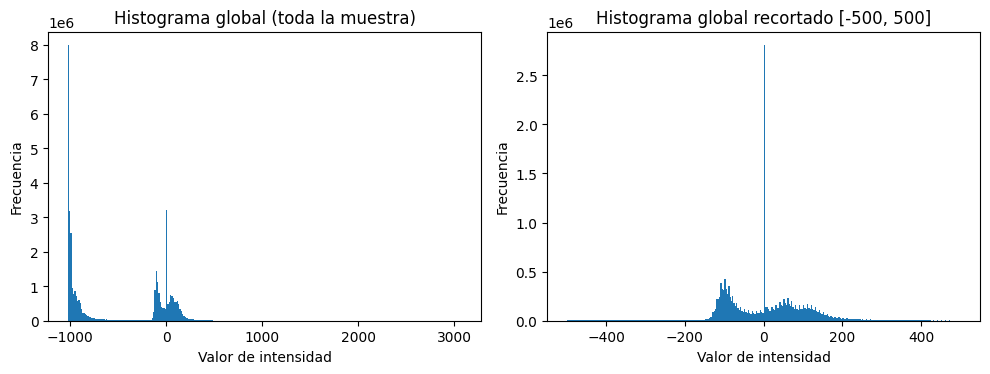

In [10]:
# ---------------------------------------------------------
# Estimar ventana global a partir de TODOS los casos
# con anotación Couinaud (imagesTr + imagesTs)
# ---------------------------------------------------------

import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

# 1) Armar mapping base -> (split, img_file) usando las listas ya matcheadas
# matched_tr / matched_ts son listas de tuplas: (base, img_file, mask_file)
base_to_image = {}

for b, img_f, _ in matched_tr:
    base_to_image[b] = ("Tr", img_f)

for b, img_f, _ in matched_ts:
    base_to_image[b] = ("Ts", img_f)

all_matched_bases = sorted(base_to_image.keys())
print("Total de casos con Couinaud (Tr+Ts):", len(all_matched_bases))

# 2) Recolectar una muestra de intensidades de cada volumen
samples = []
max_samples_per_volume = 200_000  # podés ajustar este número
rng = np.random.default_rng(42)   # reproducible

for bn in all_matched_bases:
    split, fname = base_to_image[bn]
    base_dir = IMAGES_TR_DIR if split == "Tr" else IMAGES_TS_DIR

    img_path = os.path.join(base_dir, fname)
    img_nii = nib.load(img_path)
    data = img_nii.get_fdata(dtype=np.float32)

    flat = data.ravel()
    n_vox = flat.size

    if n_vox > max_samples_per_volume:
        idx = rng.choice(n_vox, size=max_samples_per_volume, replace=False)
        samples.append(flat[idx])
    else:
        samples.append(flat)

# Concatenar todas las muestras (si hay)
if len(samples) == 0:
    raise RuntimeError("No se recolectaron muestras. Revisá que matched_tr/matched_ts tengan elementos.")

all_samples = np.concatenate(samples, axis=0)
print("Total de voxeles muestreados:", all_samples.size)

# 3) Estadísticas globales y percentiles
g_min  = float(all_samples.min())
g_max  = float(all_samples.max())
p1     = float(np.percentile(all_samples, 1))
p99    = float(np.percentile(all_samples, 99))
p5     = float(np.percentile(all_samples, 5))
p95    = float(np.percentile(all_samples, 95))

print("\nEstadísticas globales de la muestra:")
print(f"  min global     : {g_min:.2f}")
print(f"  max global     : {g_max:.2f}")
print(f"  p1 / p99       : {p1:.2f} / {p99:.2f}")
print(f"  p5 / p95       : {p5:.2f} / {p95:.2f}")

# Rango sugerido de ventana (podés cambiar la lógica si querés)
hu_min_sugerido = p5
hu_max_sugerido = p95

print(f"\nRango de ventana sugerido (basado en p5–p95):")
print(f"  range = ({hu_min_sugerido:.2f}, {hu_max_sugerido:.2f})")

# 4) Histogramas globales
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(all_samples, bins=300)
plt.title("Histograma global (toda la muestra)")
plt.xlabel("Valor de intensidad")
plt.ylabel("Frecuencia")

plt.subplot(1, 2, 2)
mask_soft = (all_samples >= -500) & (all_samples <= 500)
plt.hist(all_samples[mask_soft], bins=300)
plt.title("Histograma global recortado [-500, 500]")
plt.xlabel("Valor de intensidad")
plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()

## 8. Comparar una imagen original vs. ventaneada \[-200, 250] y normalizada \[0, 1]

En esta sección:

- Seleccionamos un solo paciente entre los que tienen anotaciones Couinaud
  (puede cambiarse fácilmente el índice del paciente).
- Cargamos el volumen de CT asociado y elegimos el corte sagital/axial central
  (en este caso, el corte central en el eje de slices).
- Mostramos:
  - la imagen original,
  - la misma imagen luego de aplicar una ventana de intensidades \[-200, 250]
    y normalizar linealmente ese rango al intervalo \[0, 1].
- Debajo de las imágenes, graficamos los histogramas de intensidades:
  - original,
  - ventaneada y normalizada.

Esto permite visualizar el efecto del ventaneo y verificar que la mayor parte
de los tejidos blandos (incluido el hígado) quedan resaltados en el rango
normalizado \[0,1].


Paciente base-name : hepaticvessel_001
Archivo            : hepaticvessel_001.nii.gz
Origen             : imagesTr
Ruta completa      : /users/lvelez/PI_Velez/data/Couinaud/imagesTr/hepaticvessel_001.nii.gz
Shape del volumen (canónico): (512, 512, 49)


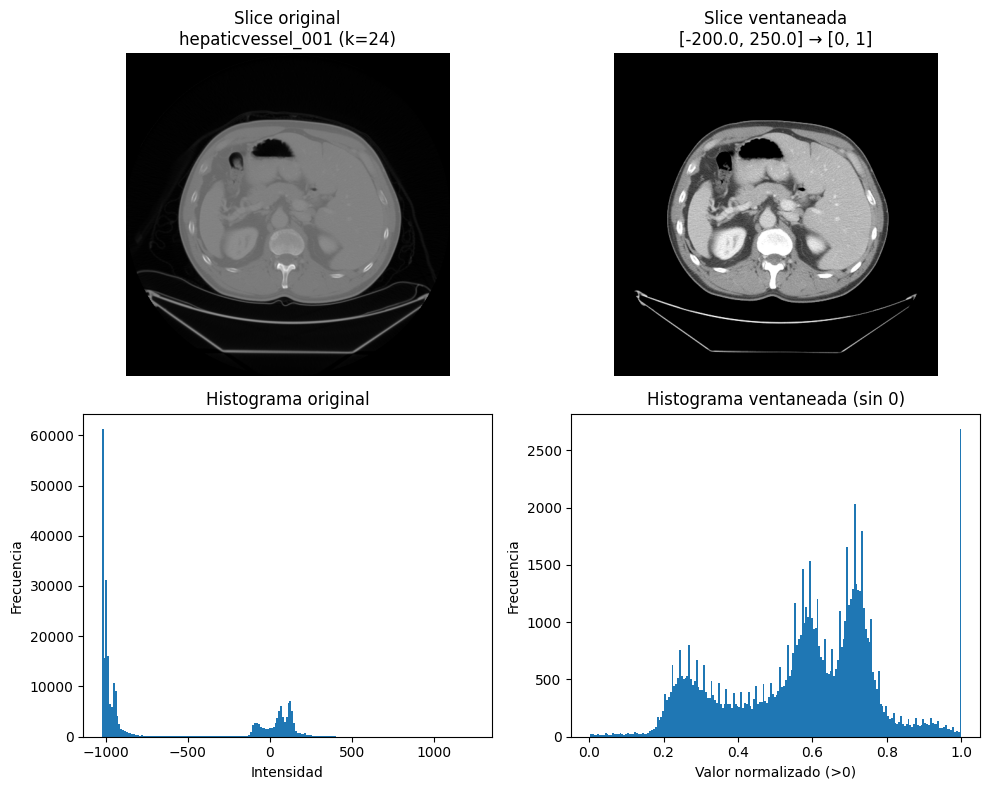

In [11]:
import os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

def apply_window_and_normalize(volume, hu_min=-200.0, hu_max=250.0):
    vol_clipped = np.clip(volume, hu_min, hu_max)
    vol_norm = (vol_clipped - hu_min) / (hu_max - hu_min)
    return vol_norm.astype(np.float32)

idx_paciente = 0  # <-- cambiá este número para ver otro caso

bn = all_matched_bases[idx_paciente]

if bn in images_tr_by_base:
    fname = images_tr_by_base[bn]["file"]
    base_dir = IMAGES_TR_DIR
    origen = "imagesTr"
elif bn in images_ts_by_base:
    fname = images_ts_by_base[bn]["file"]
    base_dir = IMAGES_TS_DIR
    origen = "imagesTs"
else:
    raise ValueError(f"No se encontró {bn} ni en imagesTr ni en imagesTs")

img_path = os.path.join(base_dir, fname)

print(f"Paciente base-name : {bn}")
print(f"Archivo            : {fname}")
print(f"Origen             : {origen}")
print(f"Ruta completa      : {img_path}")

img_nii = nib.load(img_path)
img_nii = nib.as_closest_canonical(img_nii)
data = img_nii.get_fdata(dtype=np.float32)

print("Shape del volumen (canónico):", data.shape)

kslice = data.shape[2] // 2
slice_orig = data[:, :, kslice]

slice_orig_disp = np.rot90(slice_orig, k=1)

hu_min, hu_max = -200.0, 250.0
slice_win = apply_window_and_normalize(slice_orig, hu_min, hu_max)
slice_win_disp = np.rot90(slice_win, k=1)

vals_orig = slice_orig.ravel()
vals_win = slice_win.ravel()
vals_win_nozero = vals_win[vals_win > 0.0]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0, 0].imshow(slice_orig_disp, cmap="gray")
axes[0, 0].set_title(f"Slice original\n{bn} (k={kslice})")
axes[0, 0].axis("off")

axes[0, 1].imshow(slice_win_disp, cmap="gray", vmin=0.0, vmax=1.0)
axes[0, 1].set_title(f"Slice ventaneada\n[{hu_min}, {hu_max}] → [0, 1]")
axes[0, 1].axis("off")

axes[1, 0].hist(vals_orig, bins=200)
axes[1, 0].set_title("Histograma original")
axes[1, 0].set_xlabel("Intensidad")
axes[1, 0].set_ylabel("Frecuencia")

axes[1, 1].hist(vals_win_nozero, bins=200)
axes[1, 1].set_title("Histograma ventaneada (sin 0)")
axes[1, 1].set_xlabel("Valor normalizado (>0)")
axes[1, 1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

Paciente base-name : hepaticvessel_002
Archivo            : hepaticvessel_002.nii.gz
Origen             : imagesTr
Ruta completa      : /users/lvelez/PI_Velez/data/Couinaud/imagesTr/hepaticvessel_002.nii.gz
Shape del volumen (canónico): (512, 512, 66)


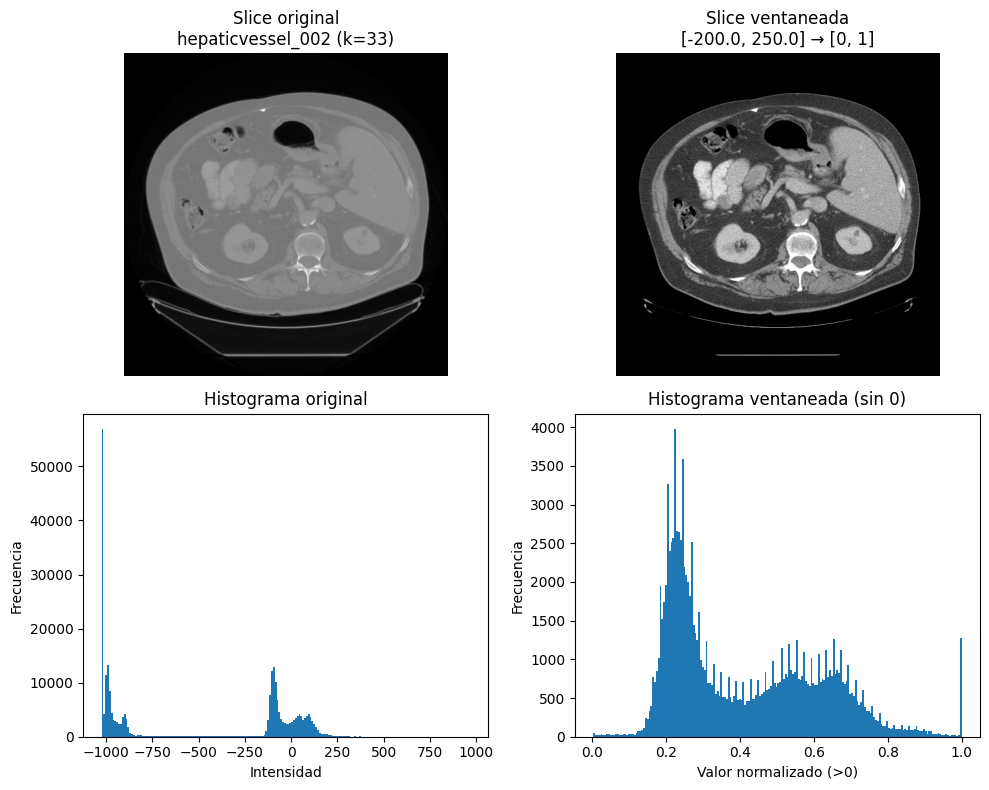

In [12]:
idx_paciente = 1  # <-- cambiá este número para ver otro caso

bn = all_matched_bases[idx_paciente]

if bn in images_tr_by_base:
    fname = images_tr_by_base[bn]["file"]
    base_dir = IMAGES_TR_DIR
    origen = "imagesTr"
elif bn in images_ts_by_base:
    fname = images_ts_by_base[bn]["file"]
    base_dir = IMAGES_TS_DIR
    origen = "imagesTs"
else:
    raise ValueError(f"No se encontró {bn} ni en imagesTr ni en imagesTs")

img_path = os.path.join(base_dir, fname)

print(f"Paciente base-name : {bn}")
print(f"Archivo            : {fname}")
print(f"Origen             : {origen}")
print(f"Ruta completa      : {img_path}")

img_nii = nib.load(img_path)
img_nii = nib.as_closest_canonical(img_nii)
data = img_nii.get_fdata(dtype=np.float32)

print("Shape del volumen (canónico):", data.shape)

kslice = data.shape[2] // 2
slice_orig = data[:, :, kslice]

slice_orig_disp = np.rot90(slice_orig, k=1)

hu_min, hu_max = -200.0, 250.0
slice_win = apply_window_and_normalize(slice_orig, hu_min, hu_max)
slice_win_disp = np.rot90(slice_win, k=1)

vals_orig = slice_orig.ravel()
vals_win = slice_win.ravel()
vals_win_nozero = vals_win[vals_win > 0.0]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0, 0].imshow(slice_orig_disp, cmap="gray")
axes[0, 0].set_title(f"Slice original\n{bn} (k={kslice})")
axes[0, 0].axis("off")

axes[0, 1].imshow(slice_win_disp, cmap="gray", vmin=0.0, vmax=1.0)
axes[0, 1].set_title(f"Slice ventaneada\n[{hu_min}, {hu_max}] → [0, 1]")
axes[0, 1].axis("off")

axes[1, 0].hist(vals_orig, bins=200)
axes[1, 0].set_title("Histograma original")
axes[1, 0].set_xlabel("Intensidad")
axes[1, 0].set_ylabel("Frecuencia")

axes[1, 1].hist(vals_win_nozero, bins=200)
axes[1, 1].set_title("Histograma ventaneada (sin 0)")
axes[1, 1].set_xlabel("Valor normalizado (>0)")
axes[1, 1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

## 9. Distribución de cantidad de slices por paciente

En esta sección queremos ver cómo se distribuye la cantidad de cortes axiales (slices)
entre los distintos pacientes que tienen anotación Couinaud.

Pasos que seguimos:

1. Recorremos la lista `matched_cases`.
2. Para cada caso, cargamos el volumen original desde `imagesTr`.
3. Tomamos la dimensión axial (por ejemplo, el eje 2: `shape[2]`) como cantidad de slices.
4. Guardamos el número de slices por paciente en una lista.
5. Graficamos un **histograma** que muestra cuántos pacientes tienen cierta cantidad de slices.

Esto nos da una idea de la variabilidad del tamaño de los volúmenes en el dataset.


Número de pacientes con máscara Couinaud (imagesTr): 161
Slices mínimos : 26
Slices máximos : 178
Slices promedio: 62.024844720496894
Slices mediana : 47.0


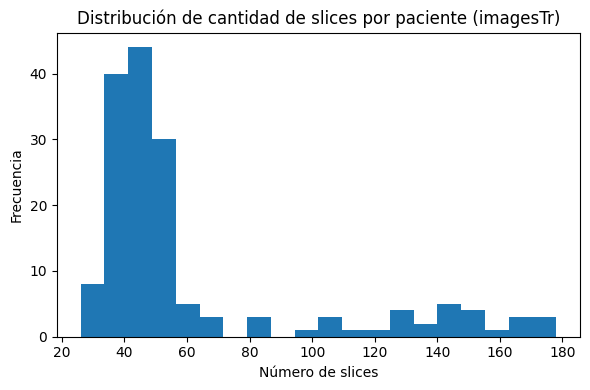

In [13]:
slices_per_patient = []

for b, img_f, _ in matched_tr:   
    img_path = os.path.join(IMAGES_TR_DIR, img_f)

    img_nii = nib.load(img_path)
    img_data = img_nii.get_fdata()

    # Asumimos eje axial = último (Z)
    num_slices = img_data.shape[2]

    slices_per_patient.append(num_slices)
    rows.append([b, img_f, num_slices])

slices_per_patient = np.array(slices_per_patient, dtype=int)

# ---- Resumen ----
print("Número de pacientes con máscara Couinaud (imagesTr):", len(slices_per_patient))
print("Slices mínimos :", int(slices_per_patient.min()))
print("Slices máximos :", int(slices_per_patient.max()))
print("Slices promedio:", float(slices_per_patient.mean()))
print("Slices mediana :", float(np.median(slices_per_patient)))

# ---- Histograma ----
plt.figure(figsize=(6, 4))
plt.hist(slices_per_patient, bins=20)
plt.title("Distribución de cantidad de slices por paciente (imagesTr)")
plt.xlabel("Número de slices")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

In [15]:
s = slices_per_patient  # array de slices por paciente (imagesTr con Couinaud)

print("Total de pacientes (imagesTr con Couinaud):", len(s))

# -----------------------------------------
# 1) Grupos en pasos de 20 slices
# -----------------------------------------
edges = list(range(0, 201, 10))  # 0,20,40,...,200

print("\nDistribución por intervalos de 10 slices:\n")

for i in range(len(edges) - 1):
    a = edges[i]
    b = edges[i + 1]
    mask = (s >= a) & (s < b)
    print(f"[{a:3d}, {b:3d}) : {mask.sum()} pacientes")

# último grupo: >= 200
mask_ge_200 = (s >= 200)
print(f"[200,  inf) : {mask_ge_200.sum()} pacientes")

# -----------------------------------------
# 2) Pacientes con cantidad EXACTA
#    en múltiplos de 40
# -----------------------------------------
multiples_40 = [40, 80, 120, 160, 200]

print("\nPacientes con cantidad EXACTA de slices (múltiplos de 40):\n")
for m in multiples_40:
    count_m = (s == m).sum()
    print(f"== {m:3d} : {count_m} pacientes")

Total de pacientes (imagesTr con Couinaud): 161

Distribución por intervalos de 10 slices:

[  0,  10) : 0 pacientes
[ 10,  20) : 0 pacientes
[ 20,  30) : 2 pacientes
[ 30,  40) : 33 pacientes
[ 40,  50) : 65 pacientes
[ 50,  60) : 25 pacientes
[ 60,  70) : 4 pacientes
[ 70,  80) : 1 pacientes
[ 80,  90) : 3 pacientes
[ 90, 100) : 1 pacientes
[100, 110) : 3 pacientes
[110, 120) : 1 pacientes
[120, 130) : 3 pacientes
[130, 140) : 4 pacientes
[140, 150) : 5 pacientes
[150, 160) : 4 pacientes
[160, 170) : 4 pacientes
[170, 180) : 3 pacientes
[180, 190) : 0 pacientes
[190, 200) : 0 pacientes
[200,  inf) : 0 pacientes

Pacientes con cantidad EXACTA de slices (múltiplos de 40):

==  40 : 6 pacientes
==  80 : 1 pacientes
== 120 : 0 pacientes
== 160 : 0 pacientes
== 200 : 0 pacientes
